In [5]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import gymnasium as gym

import jlab_opt_control.envs as custom_gym
import jlab_opt_control.agents as agents

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import logging
run_openai_log = logging.getLogger("RunOpenAI")
run_openai_log.setLevel(logging.INFO)
logging.basicConfig(format='%(asctime)s %(levelname)s:%(name)s:%(message)s')

In [7]:
 # Environment
env_id = 'Pendulum-v1'
run_openai_log.info('Running env: {}'.format(env_id))

if env_id in gym.envs.registry:
    env = gym.make(env_id)
elif env_id in custom_gym.list_registered_modules():
    env = custom_gym.make(env_id)

num_states = env.observation_space.shape[0]
run_openai_log.info("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
run_openai_log.info("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

run_openai_log.info("Max Value of Action ->  {}".format(upper_bound))
run_openai_log.info("Min Value of Action ->  {}".format(lower_bound))

2024-05-30 15:59:40,582 INFO:RunOpenAI:Running env: Pendulum-v1
2024-05-30 15:59:40,587 INFO:RunOpenAI:Size of State Space ->  3
2024-05-30 15:59:40,588 INFO:RunOpenAI:Size of Action Space ->  1
2024-05-30 15:59:40,588 INFO:RunOpenAI:Max Value of Action ->  2.0
2024-05-30 15:59:40,588 INFO:RunOpenAI:Min Value of Action ->  -2.0


In [8]:
import os
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.INFO)
logging.getLogger("TD3-Agent").setLevel(logging.INFO)

# Agent
agent_id = 'KerasTD3-v0'
logdir = './results/Pendulum/index0_agent_KerasTD3-v0_buf_cfg_bsize_cfg_env_Pendulum-v1_hash5b5bc25_results_20240523-114909'
os.makedirs(logdir, exist_ok=True)
buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

agent.model_load_path = f'{logdir}/models/epoch_62_057/'
agent.load()

2024-05-30 15:59:50,841 INFO:Agent Registry:Making new agent: KerasTD3-v0 ({'env': <TimeLimit<OrderEnforcing<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>, 'logdir': './results/Pendulum/index0_agent_KerasTD3-v0_buf_cfg_bsize_cfg_env_Pendulum-v1_hash5b5bc25_results_20240523-114909', 'buffer_type': 'ER-v0', 'buffer_size': None})
2024-05-30 15:59:50,842 INFO:TD3-Agent:Running KerasTD3 __init__
2024-05-30 15:59:50,842 INFO:TD3-Agent:Action upper bound: [2.]
2024-05-30 15:59:50,842 INFO:TD3-Agent:Action upper bound: 2.0
2024-05-30 15:59:50,843 INFO:TD3-Agent:Action lower bound: [-2.]
2024-05-30 15:59:50,843 INFO:TD3-Agent:Action lower bound: -2.0
2024-05-30 15:59:50,843 INFO:TD3-Agent:Action range: [4.]
2024-05-30 15:59:50,844 ERROR:CfgLogger:Problem with key request using None
2024-05-30 15:59:50,848 INFO:Buffer:Buffer config saved successfully
2024-05-30 15:59:50,848 INFO:TD3-Agent:Using legacy Adam
2024-05-30 15:59:50,849 INFO:TD3-Agent:Running KerasTD3 initialize_new_models()
2024-05-3

Attempting to load jlab_opt_control.agents with KerasTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN


2024-05-30 15:59:51,049 INFO:TD3-Agent:Models loaded successfully


# TD3 Model

Text(0.5, 0.98, 'TD3 Agent')

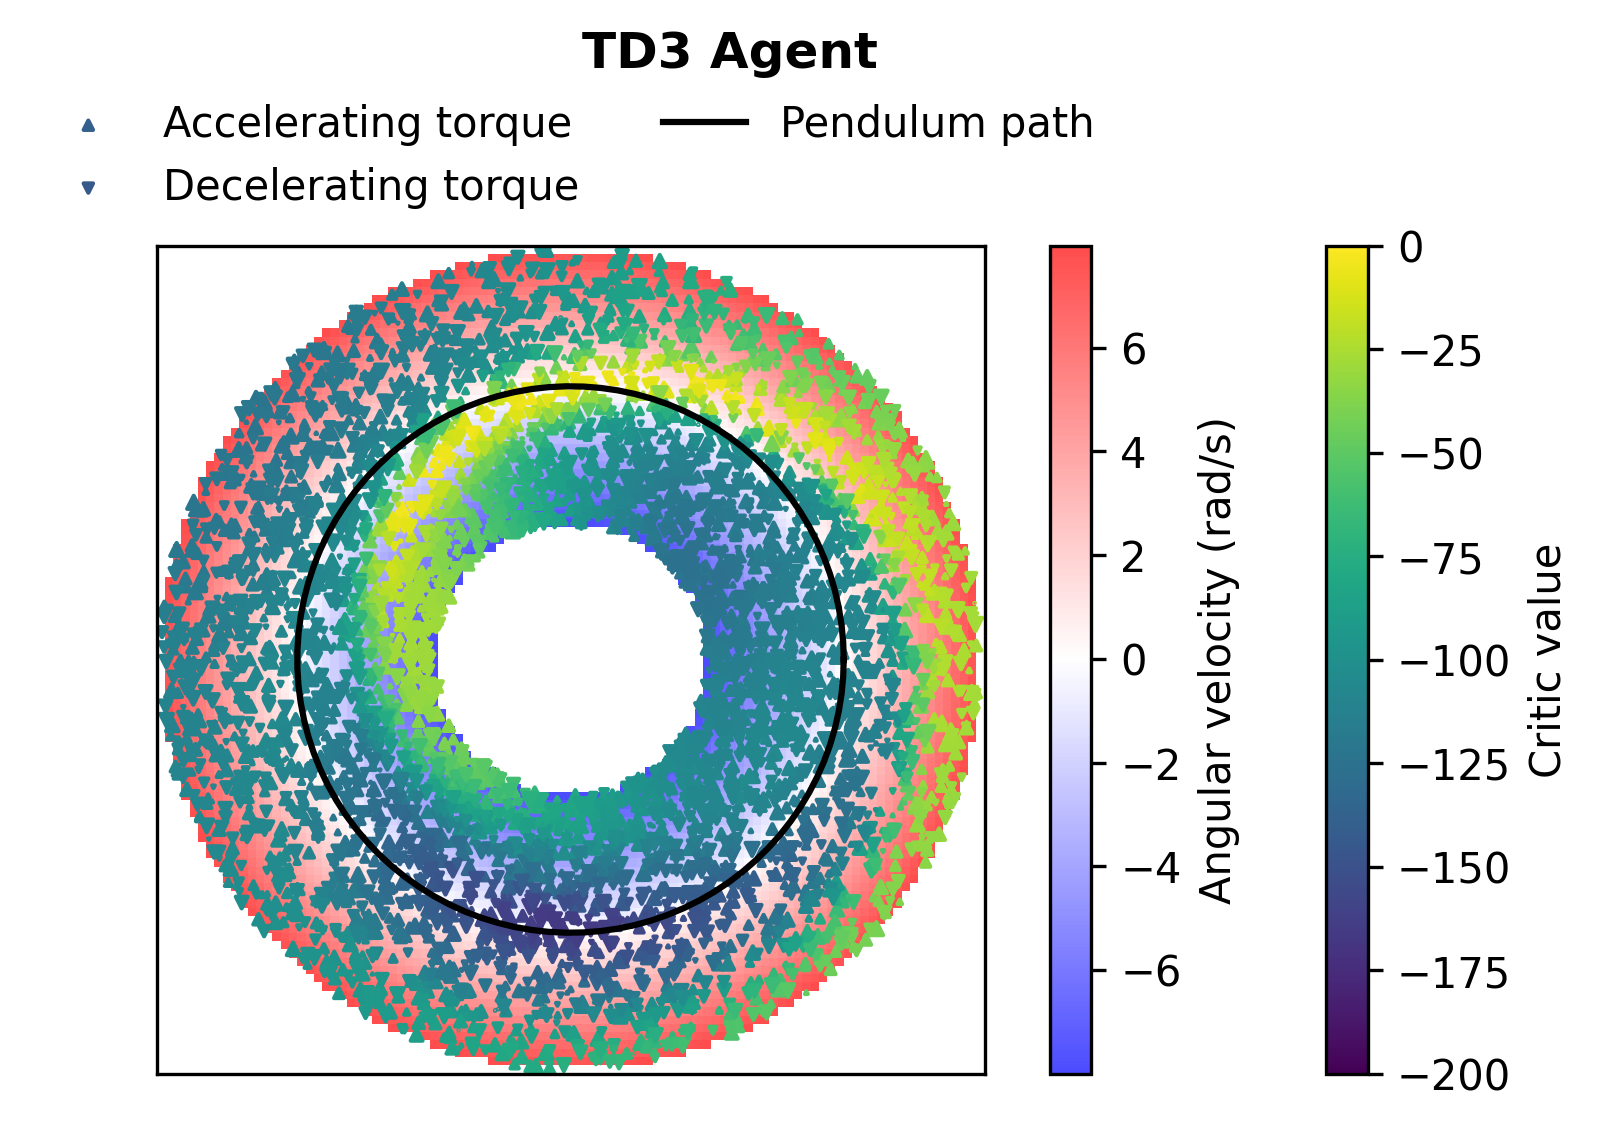

In [16]:
n_train = 5000

# Training
theta = np.random.uniform(low=0, high=2*np.pi, size=(n_train, 1))
#theta = np.random.uniform(low=-np.pi, high=np.pi, size=(n_train, 1))
omega = np.random.uniform(low=-8, high=8, size=(n_train, 1))
states = np.concatenate([np.cos(theta), np.sin(theta), omega], axis=1)
actions = np.random.uniform(low=env.action_space.low, high=env.action_space.high, size=(n_train, env.action_space.shape[0]))

test_theta = np.random.uniform(low=0, high=2*np.pi, size=(n_train, 1))
#test_theta = np.random.uniform(low=-np.pi, high=np.pi, size=(n_train, 1))
test_omega = np.random.uniform(low=-8, high=8, size=(n_train, 1))
test_states = np.concatenate([np.cos(test_theta), np.sin(test_theta), test_omega], axis=1)
test_actions = np.random.uniform(env.action_space.low, env.action_space.high, size=(n_train, env.action_space.shape[0]))

critic_values = agent.critic_model1(states, actions, training=False).numpy()
actor_values = agent.actor_model(states, training=False).numpy()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, dpi=300, figsize=(7, 4))

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=critic_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=critic_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

fig.subplots_adjust(top=0.8)
fig.suptitle('TD3 Agent', fontweight='bold')

# SINDy with $(x, y, \omega, \tau)$

(10000, 3) (10000, 1) (10000, 1) (10000, 1)
(10000, 4) (10000, 1)
Q = 12219762876.2 1 + 26.8 x + -9164822234.6 x^2 + 0.2 x w + -9164822238.2 y^2 + -5.7 y w + 0.7 w^2 + 0.2 w T + 17.5 x^3 + 9.2 x y^2 + -5.4 x y w + -1.0 x w^2 + -0.1 x T^2 + -3054940744.3 x^4 + -6109881490.3 x^2 y^2 + -3.9 x^2 y w + 0.1 x^2 w^2 + -0.1 x^2 w T + -0.2 x^2 T^2 + -3054940747.9 y^4 + -1.8 y^3 w + 0.7 y^2 w^2 + 0.2 y^2 T^2 + 0.1 y w T^2 + -0.1 T^4
R2 score is 0.812


Text(0.5, 0.98, 'SINDy $(x, y, \\omega, \\tau)$: 32 terms')

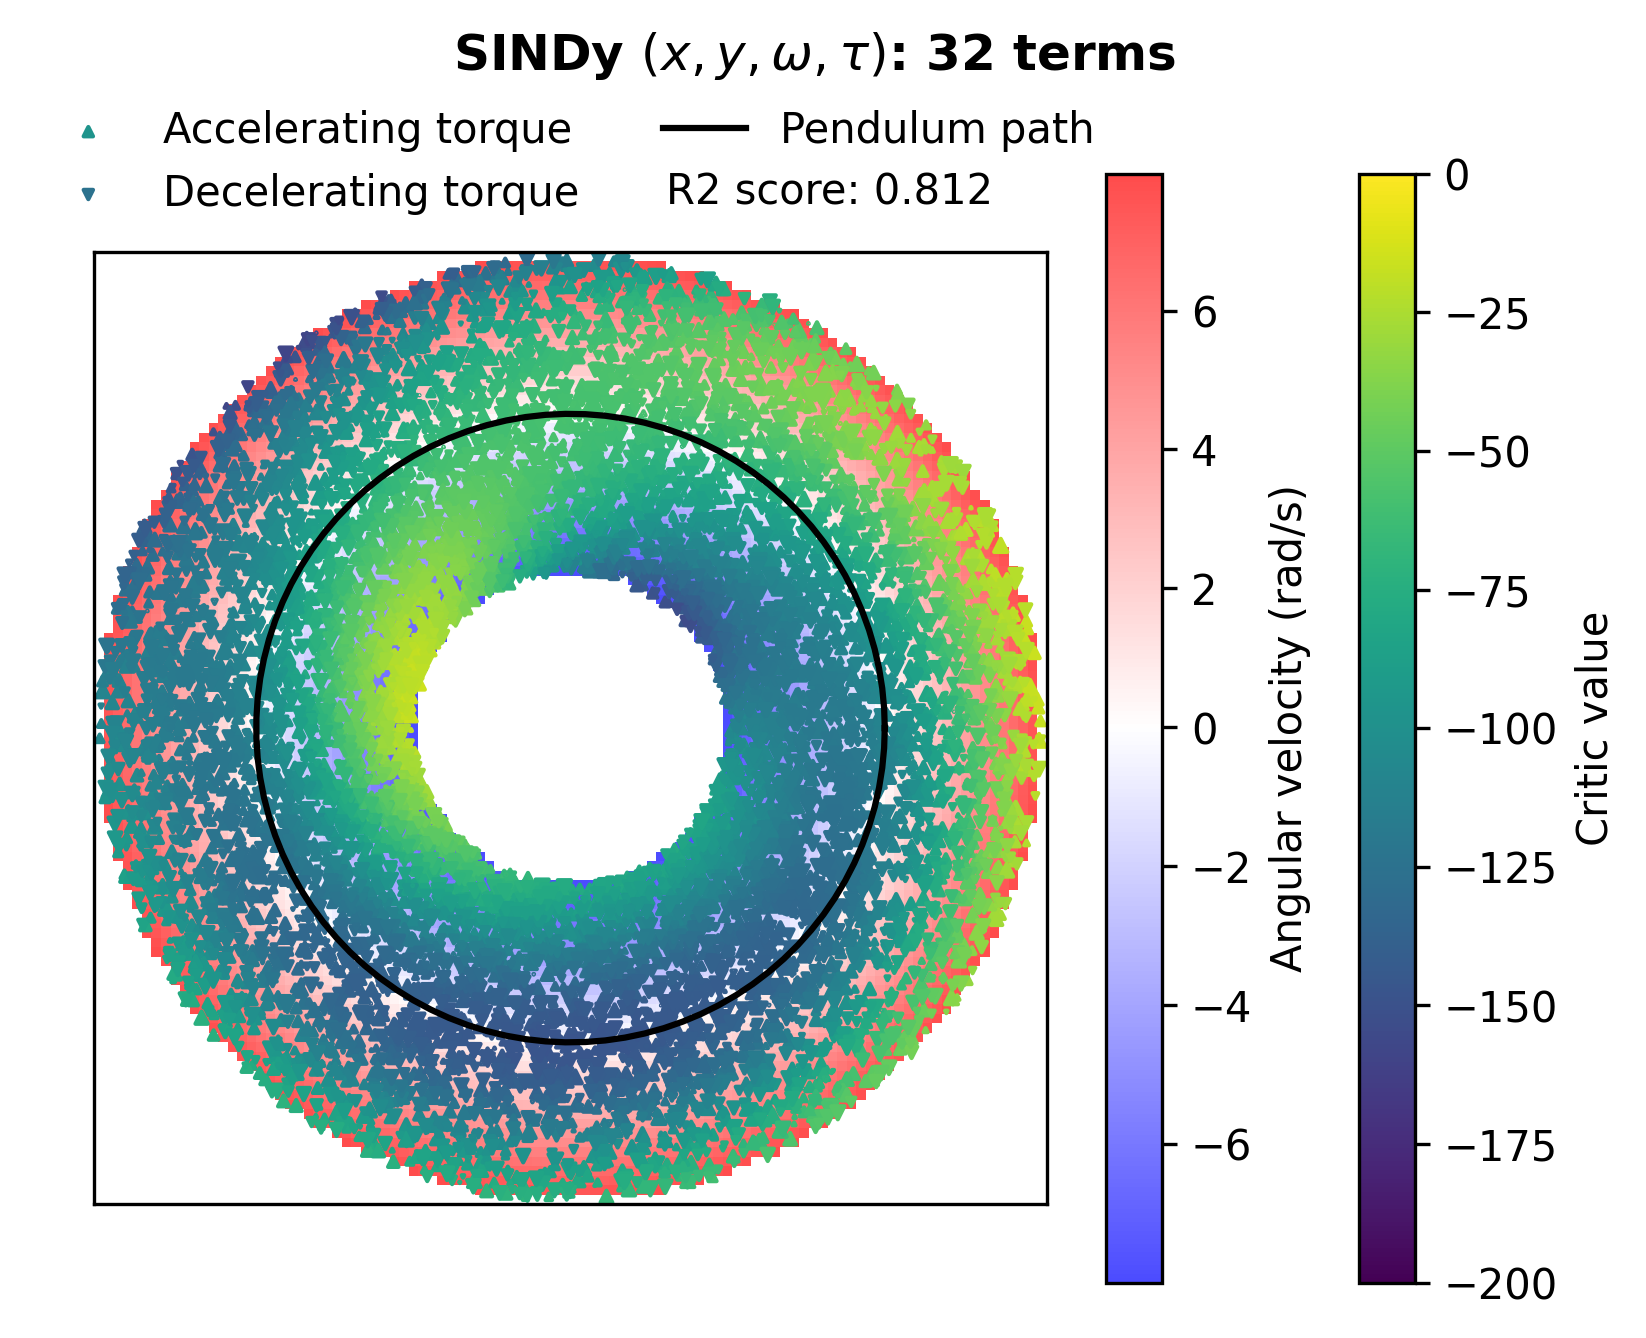

In [358]:
import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=4, include_bias=True, include_interaction=True),
    optimizer=ps.STLSQ(threshold=1e-1, alpha=2e3, normalize_columns=True),
    feature_names=['x', 'y', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(x, y, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

(10000, 3) (10000, 1) (10000, 1) (10000, 1)
(10000, 4) (10000, 1)
Q = 413479104.817 1 + 25.090 x + 0.133 y + -0.257 w + 0.344 T + -287637708.159 x^2 + 2.108 x y + 0.133 x w + -0.506 x T + -287637716.639 y^2 + -5.617 y w + -0.213 y T + 0.654 w^2 + 0.330 w T + 0.304 T^2 + 19.963 x^3 + -0.689 x^2 y + -0.218 x^2 w + -0.207 x^2 T + 5.114 x y^2 + -12.123 x y w + -0.764 x y T + -1.270 x w^2 + -0.191 x w T + 0.448 x T^2 + 0.822 y^3 + -0.040 y^2 w + 0.552 y^2 T + -0.038 y w^2 + -0.051 y w T + 0.097 y T^2 + 0.020 w^3 + 0.091 w T^2 + -0.175 T^3 + -107864137.523 x^4 + 1.383 x^3 y + 0.136 x^3 w + -0.007 x^3 T + -179773570.636 x^2 y^2 + -5.378 x^2 y w + 0.145 x^2 y T + -0.287 x^2 w^2 + 0.090 x^2 w T + 0.180 x^2 T^2 + 0.724 x y^3 + -0.004 x y^2 w + -0.498 x y^2 T + -0.067 x y w^2 + -0.104 x y w T + -0.231 x y T^2 + -0.017 x w^3 + 0.009 x w^2 T + 0.058 x w T^2 + 0.225 x T^3 + -107864146.004 y^4 + -0.239 y^3 w + -0.358 y^3 T + 0.941 y^2 w^2 + 0.240 y^2 w T + 0.124 y^2 T^2 + -0.023 y w^3 + -0.047 y w^2 

Text(0.5, 0.98, 'SINDy $(x, y, \\omega, \\tau)$: 210 terms')

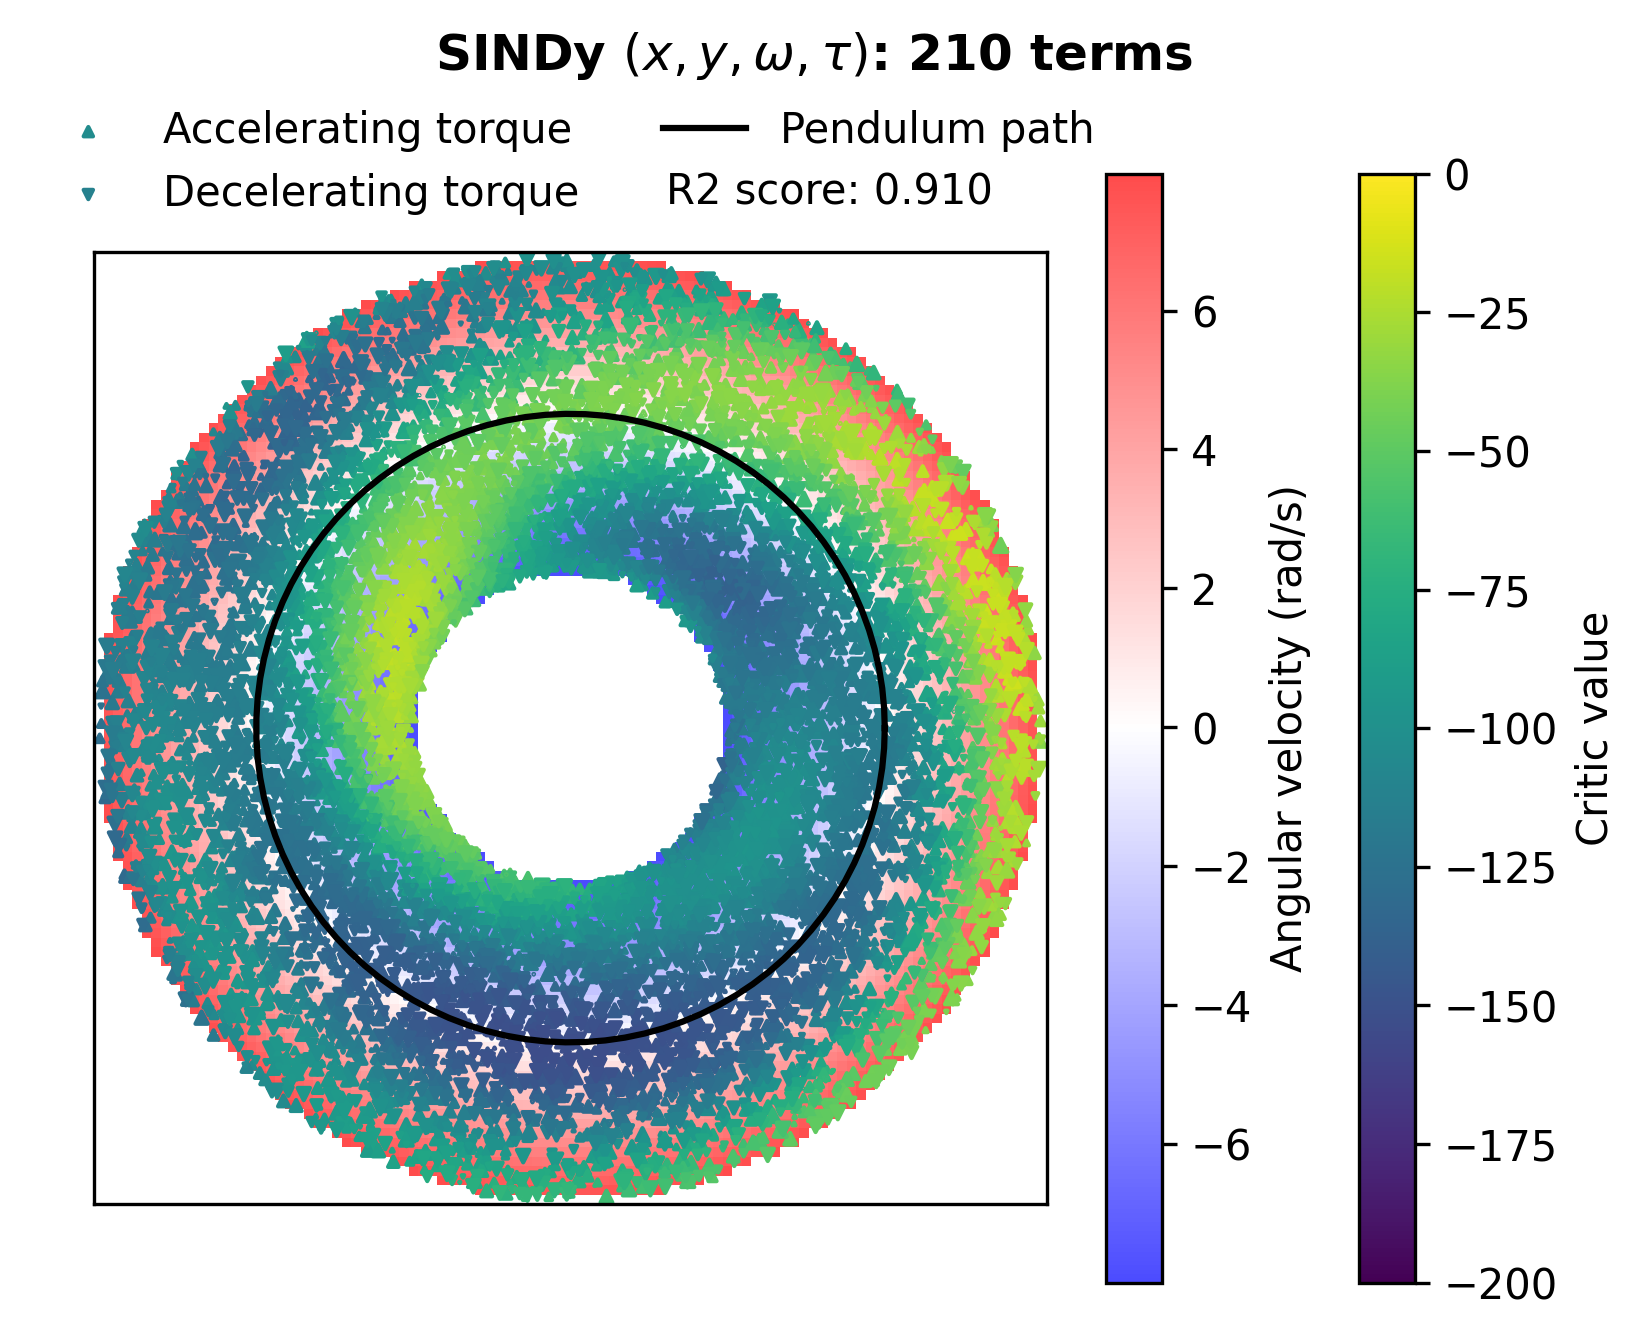

In [355]:
import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=6, include_bias=True, include_interaction=True),
    #optimizer=ps.STLSQ(threshold=2e-1, alpha=2e3, normalize_columns=True),
    optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['x', 'y', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(x, y, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

# SINDy with $(\theta, \omega, \tau)$

(10000, 3) (10000, 1) (10000, 1) (10000, 1)
(10000, 3) (10000, 1)
Q = -53.3 1 + -17.9 th + -23.4 th^2 + -10.6 th w + -0.6 w^2 + -0.5 T^2 + 8.4 th^3 + 5.2 th^2 w + 1.6 th w^2 + 0.3 th T^2 + -0.7 th^4 + -0.5 th^3 w + -0.3 th^2 w^2 + -0.1 T^4
R2 score is 0.788


Text(0.5, 0.98, 'SINDy $(\\theta, \\omega, \\tau)$: 18 terms')

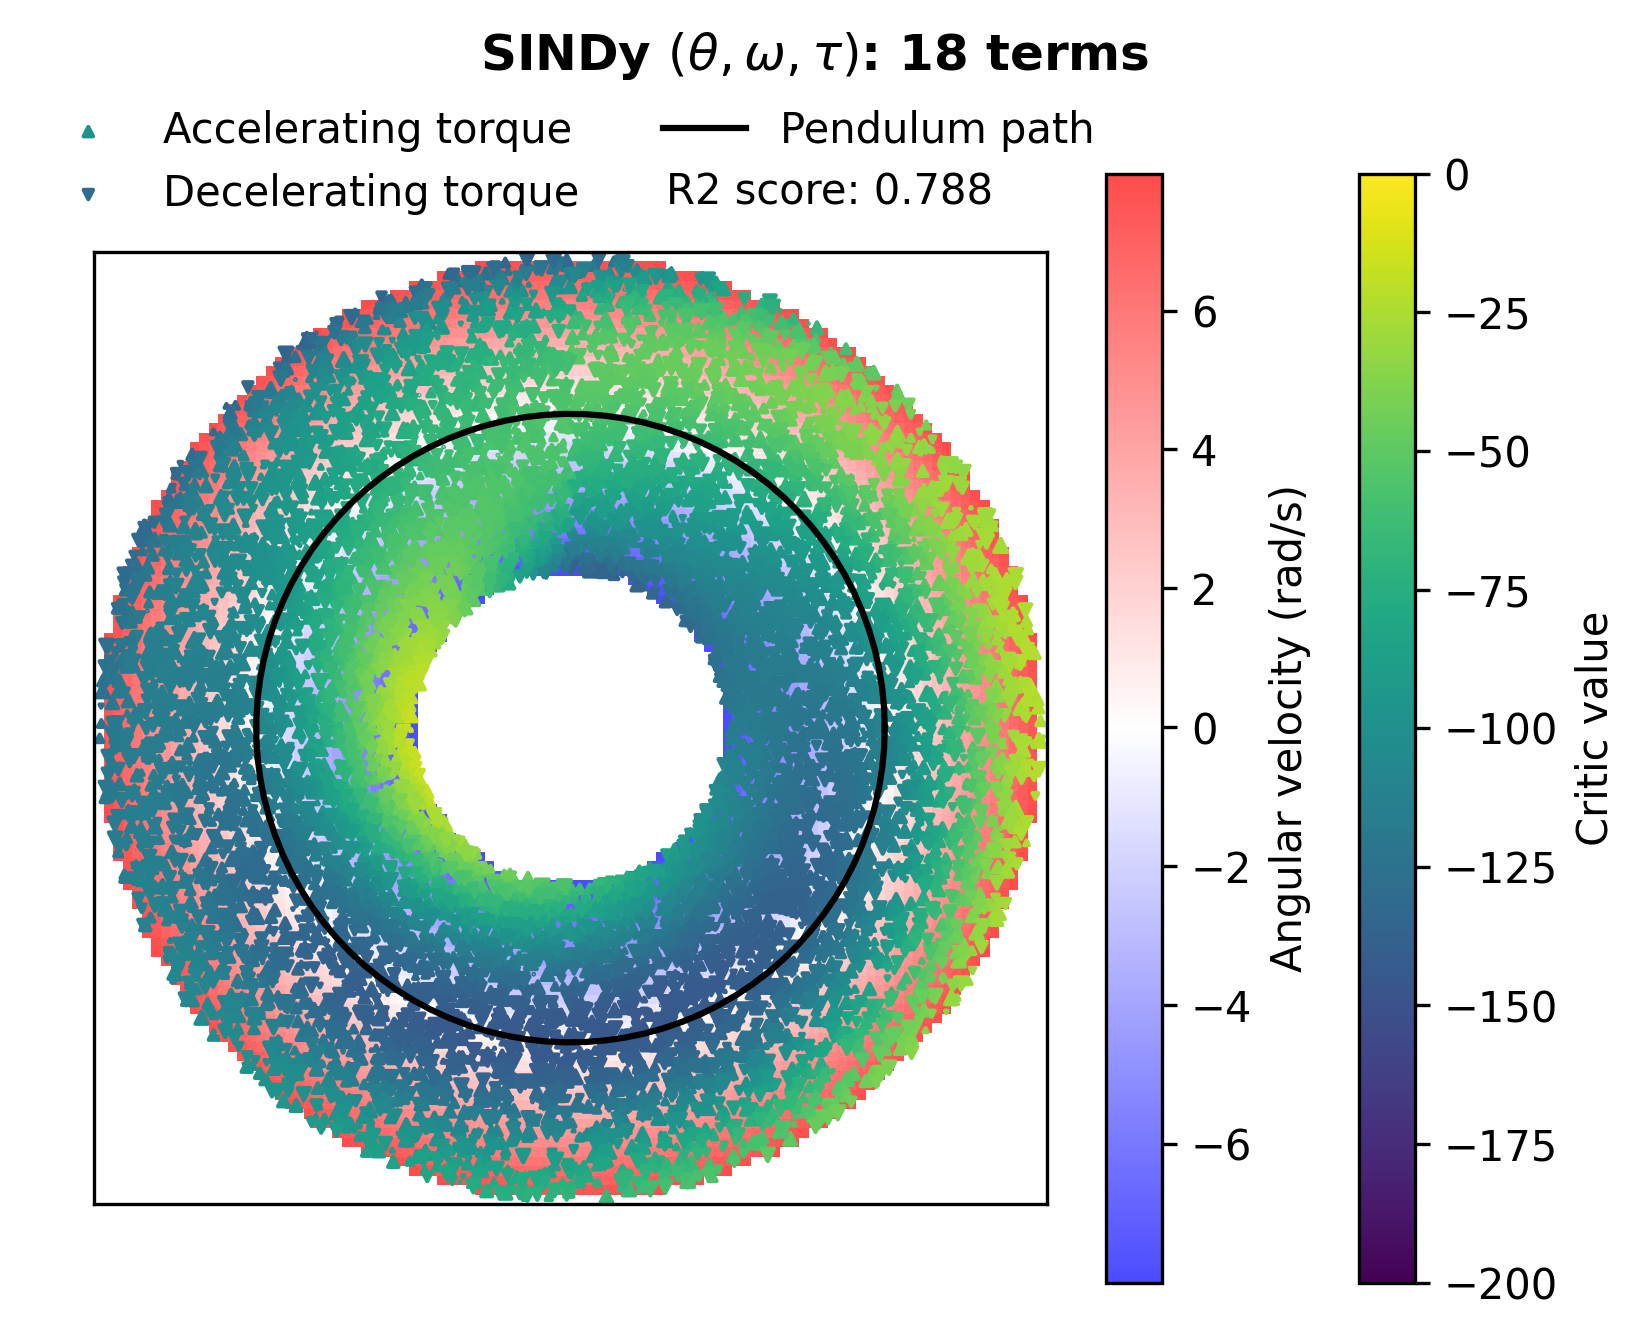

In [340]:
# Using theta instead of x and y

import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=4, include_bias=True, include_interaction=True),
    optimizer=ps.STLSQ(threshold=1e0, alpha=1e3, normalize_columns=True),
    #optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['th', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(\\theta, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

(10000, 3) (10000, 1) (10000, 1) (10000, 1)
(10000, 3) (10000, 1)
Q = -32.4 1 + -79.0 th + -10.9 w + -3.8 T + 55.2 th^2 + -15.2 th w + 5.5 th T + -3.1 w^2 + -1.0 T^2 + -40.5 th^3 + 20.7 th^2 w + -1.7 th^2 T + 4.2 th w^2 + 0.8 th w T + 1.2 th T^2 + 0.5 w^3 + 0.1 w^2 T + -0.1 w T^2 + -0.5 T^3 + 14.1 th^4 + -8.5 th^3 w + -0.9 th^2 w^2 + -0.3 th^2 w T + -1.0 th^2 T^2 + -0.3 th w^3 + -0.1 th w^2 T + 0.2 th w T^2 + -1.1 th T^3 + 0.1 w^2 T^2 + -0.2 w T^3 + -0.3 T^4 + -2.1 th^5 + 1.5 th^4 w + 0.1 th^4 T + 0.1 th^3 w^2 + 0.1 th^3 w T + 0.3 th^3 T^2 + 0.1 th^2 w^3 + -0.1 th^2 w T^2 + 0.5 th^2 T^3 + 0.1 w T^4 + 0.2 T^5 + 0.1 th^6 + -0.1 th^5 w + 0.1 T^6
R2 score is 0.870


Text(0.5, 0.98, 'SINDy $(\\theta, \\omega, \\tau)$: 84 terms')

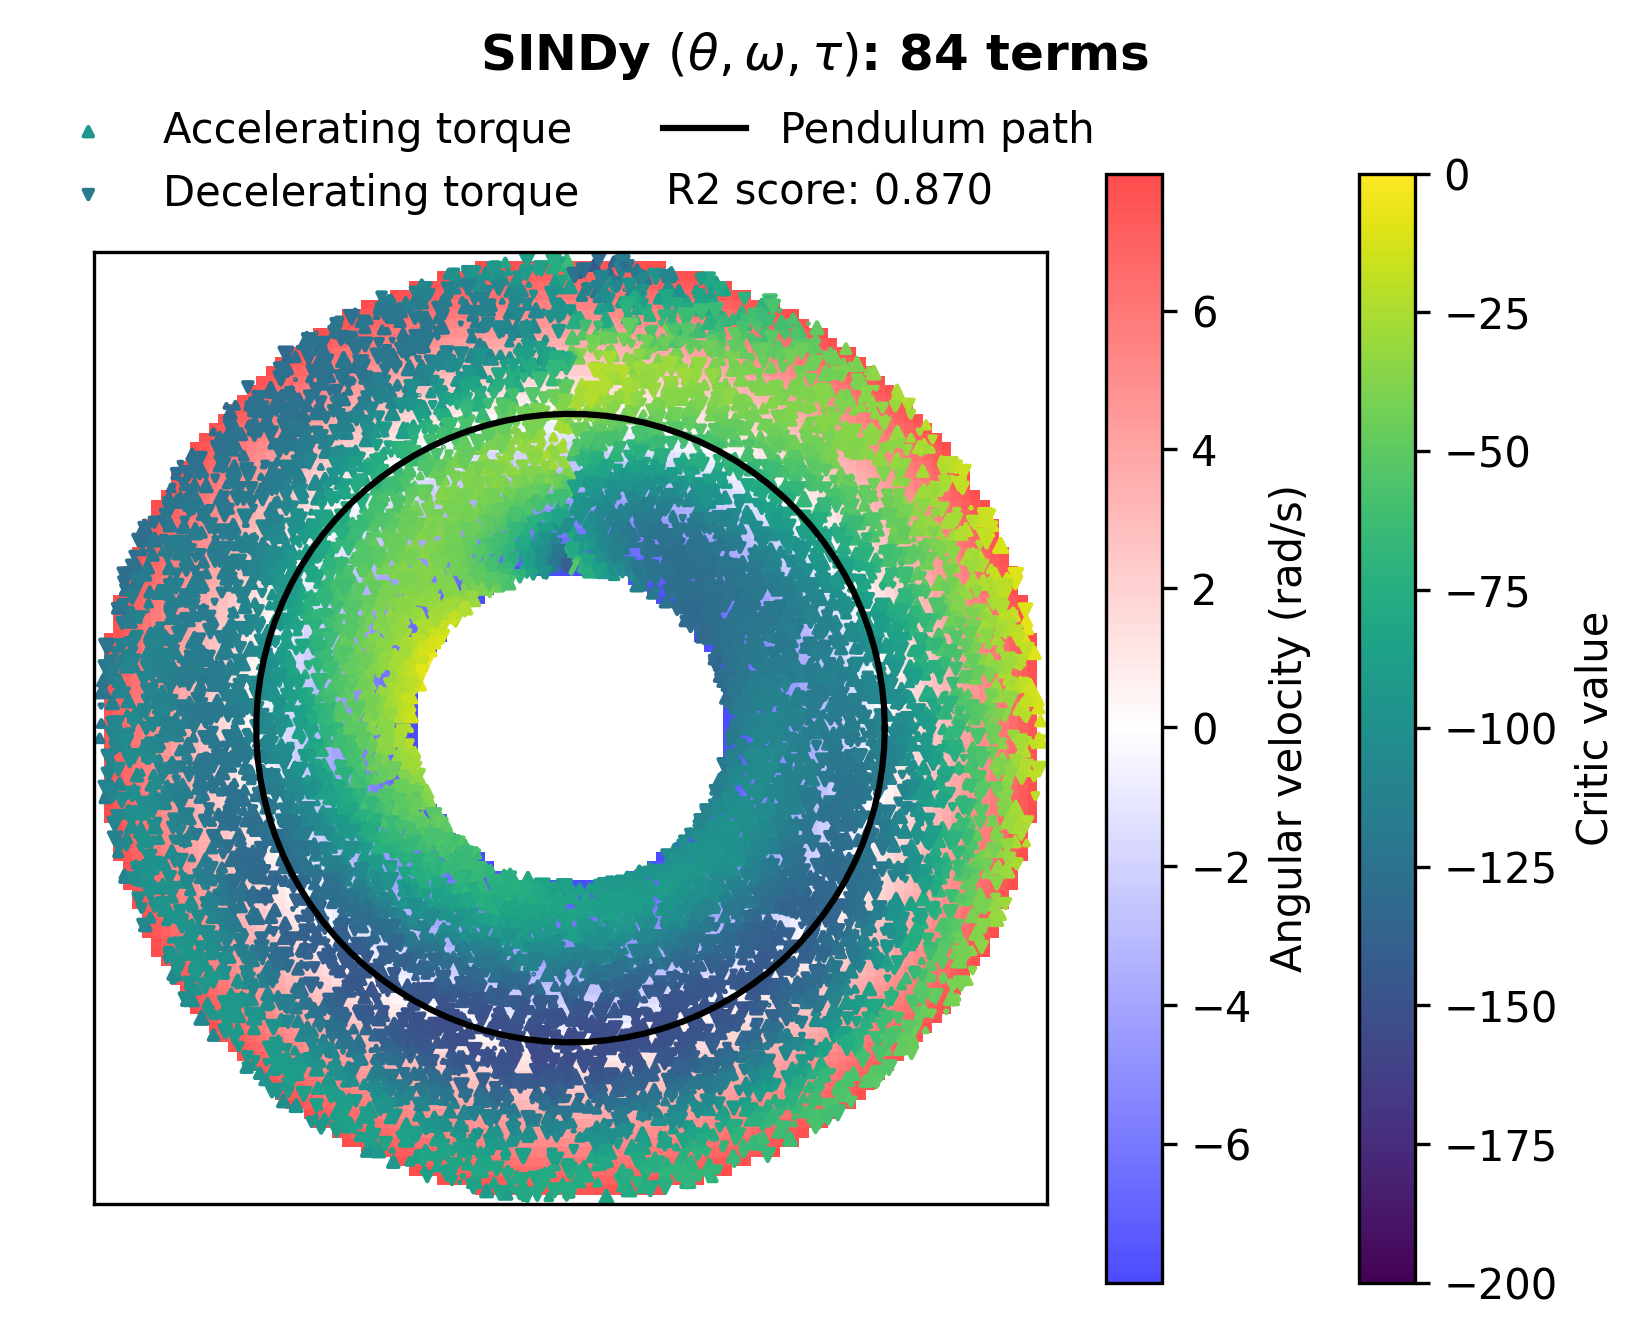

In [342]:
# Using theta instead of x and y

import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=6, include_bias=True, include_interaction=True),
    #optimizer=ps.STLSQ(threshold=1e0, alpha=1e3, normalize_columns=True),
    optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['th', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(\\theta, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

# SINDy with $(\theta, x, y, \omega, \tau)$

(10000, 3) (10000, 1) (10000, 1) (10000, 1)
(10000, 5) (10000, 1)
Q = 352633611.426 1 + -3904103.928 th + -89042056.186 x, + 8293256.768 y + -14827249.687 w + -71585768.541 T + -49943307.538 th^2 + 383236.210 th x, + -39401265.671 th y + 445064.343 th w + -413824157.668 th T + -86510839.217 x,^2 + -4206859.528 x, y + 51542258.505 x, w + 190961497.246 x, T + -39600569.845 y^2 + -15324685.935 y w + -246986293.247 y T + -30759348.138 w^2 + -232986596.985 w T + -431511085.513 T^2 + -2698147.121 th^3 + -28345769.695 th^2 x, + 6357582.551 th^2 y + -447163920.200 th^2 w + -609939446.291 th^2 T + 2419736.544 th x,^2 + -41165579.905 th x, y + -252710634.876 th x, w + 380354134.591 th x, T + -1420681.885 th y^2 + 98255358.439 th y w + -134735023.110 th y T + 618401220.510 th w^2 + -138567249.208 th w T + -222338824.563 th T^2 + -61739330.938 x,^3 + 2080900.217 x,^2 y + 165487486.588 x,^2 w + 299868566.568 x,^2 T + -35007315.686 x, y^2 + 114602936.585 x, y w + 40471316.230 x, y T + -111201208.568

Text(0.5, 0.98, 'SINDy $(\\theta, x, y, \\omega, \\tau)$: 462 terms')

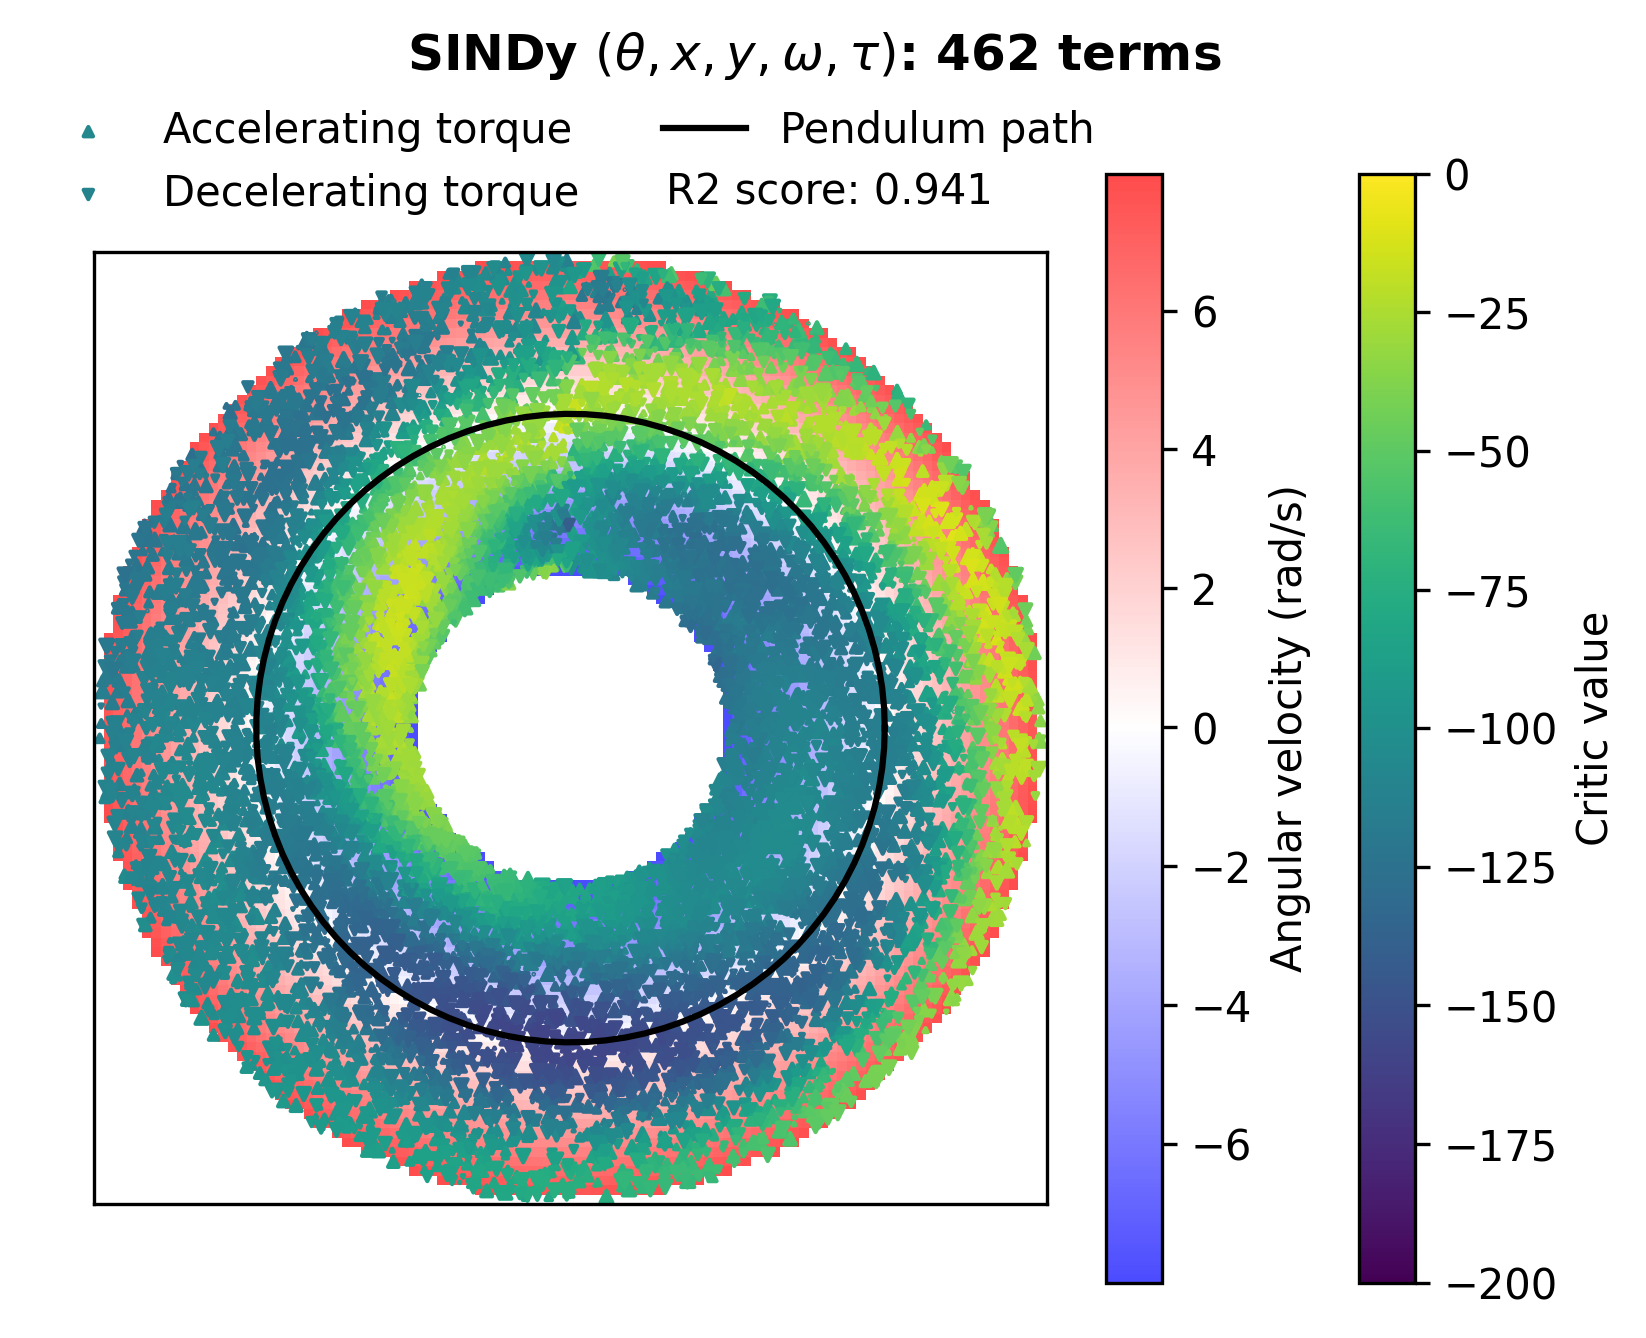

In [334]:
# Using theta and x and y

import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([theta, np.cos(theta), np.sin(theta), omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, np.cos(test_theta), np.sin(test_theta), test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=6, include_bias=True, include_interaction=True),
    #optimizer=ps.STLSQ(threshold=2e-1, alpha=5e3, normalize_columns=True),
    optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['th', 'x,', 'y', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(\\theta, x, y, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

# Parameter sweep results on SINDy

In [343]:
# Let's do a parameter sweep
import pandas as pd
results = pd.DataFrame(columns=['degree', 'interaction', 'score', 'num_terms', 'library'])

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

threshold=0
alpha=10

for degree in range(1, 7):
    for interaction in [True, False]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$x, y, \\omega, \\tau$']

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True, False]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, \\omega, \\tau$']

inputs = np.concatenate([theta, np.cos(theta), np.sin(theta), omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, np.cos(test_theta), np.sin(test_theta), test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True, False]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, x, y, \\omega, \\tau$']

results


(10000, 4) (10000, 1)
(10000, 3) (10000, 1)
(10000, 5) (10000, 1)


,degree,interaction,score,num_terms,library
0,1,True,0.139724,5,"$x, y, \omega, \tau$"
1,1,False,0.139724,5,"$x, y, \omega, \tau$"
2,2,True,0.588561,15,"$x, y, \omega, \tau$"
3,2,False,0.219352,9,"$x, y, \omega, \tau$"
4,3,True,0.790774,35,"$x, y, \omega, \tau$"
5,3,False,0.221545,13,"$x, y, \omega, \tau$"
6,4,True,0.814212,70,"$x, y, \omega, \tau$"
7,4,False,0.230026,17,"$x, y, \omega, \tau$"
8,5,True,0.892020,126,"$x, y, \omega, \tau$"
9,5,False,0.229235,21,"$x, y, \omega, \tau$"


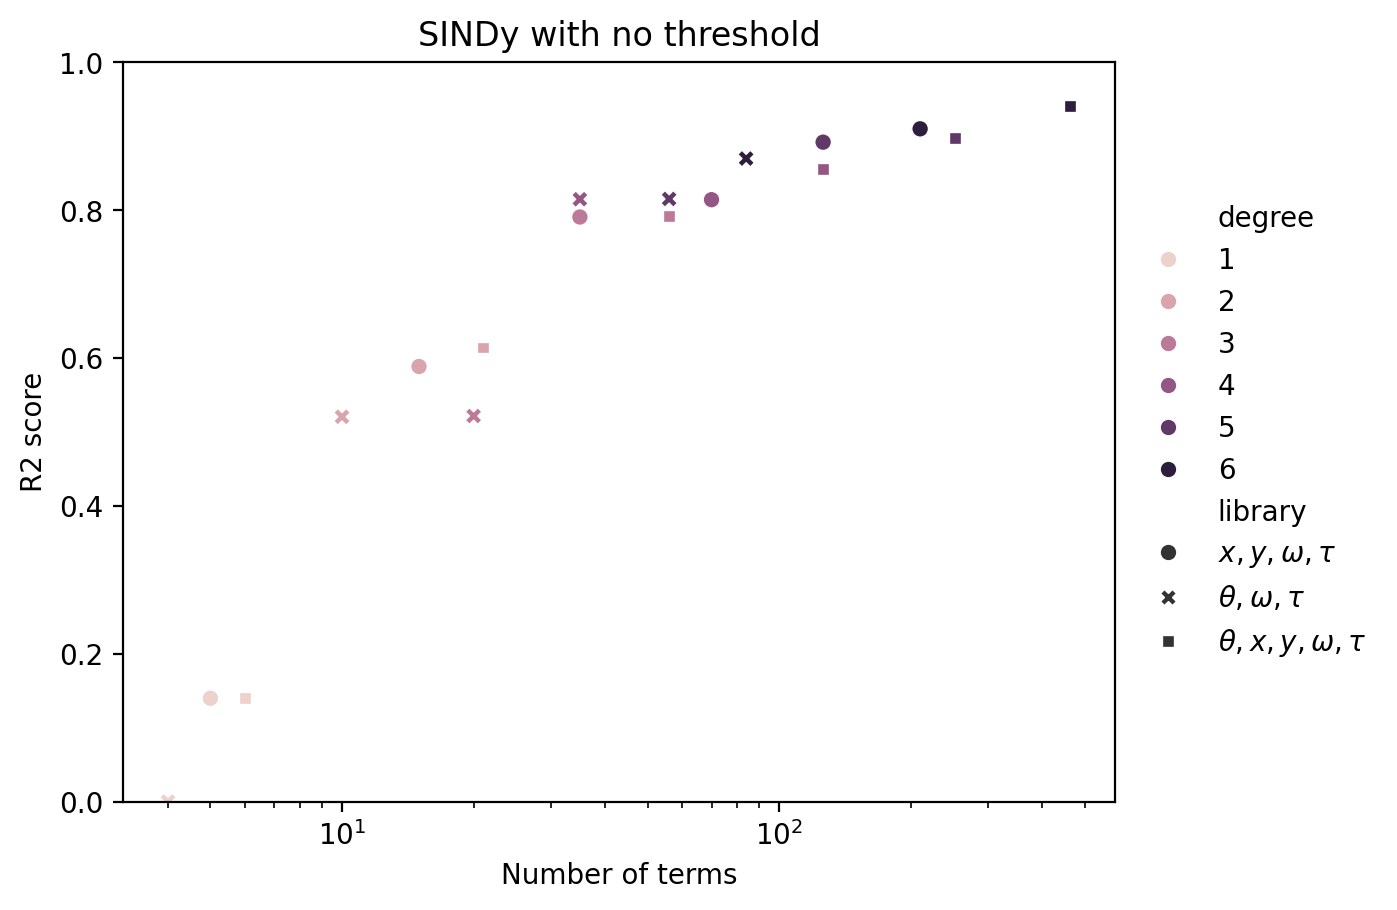

In [344]:
import seaborn as sns
plt.rcParams['figure.dpi'] = 200
p = sns.scatterplot(
    data=results[results.interaction],
    x='num_terms',
    y='score',
    hue='degree',
    style='library',
)
p.set(xscale='log', ylim=[0, 1])
p.set(xlabel='Number of terms', ylabel='R2 score', title='SINDy with no threshold')
sns.move_legend(p, loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

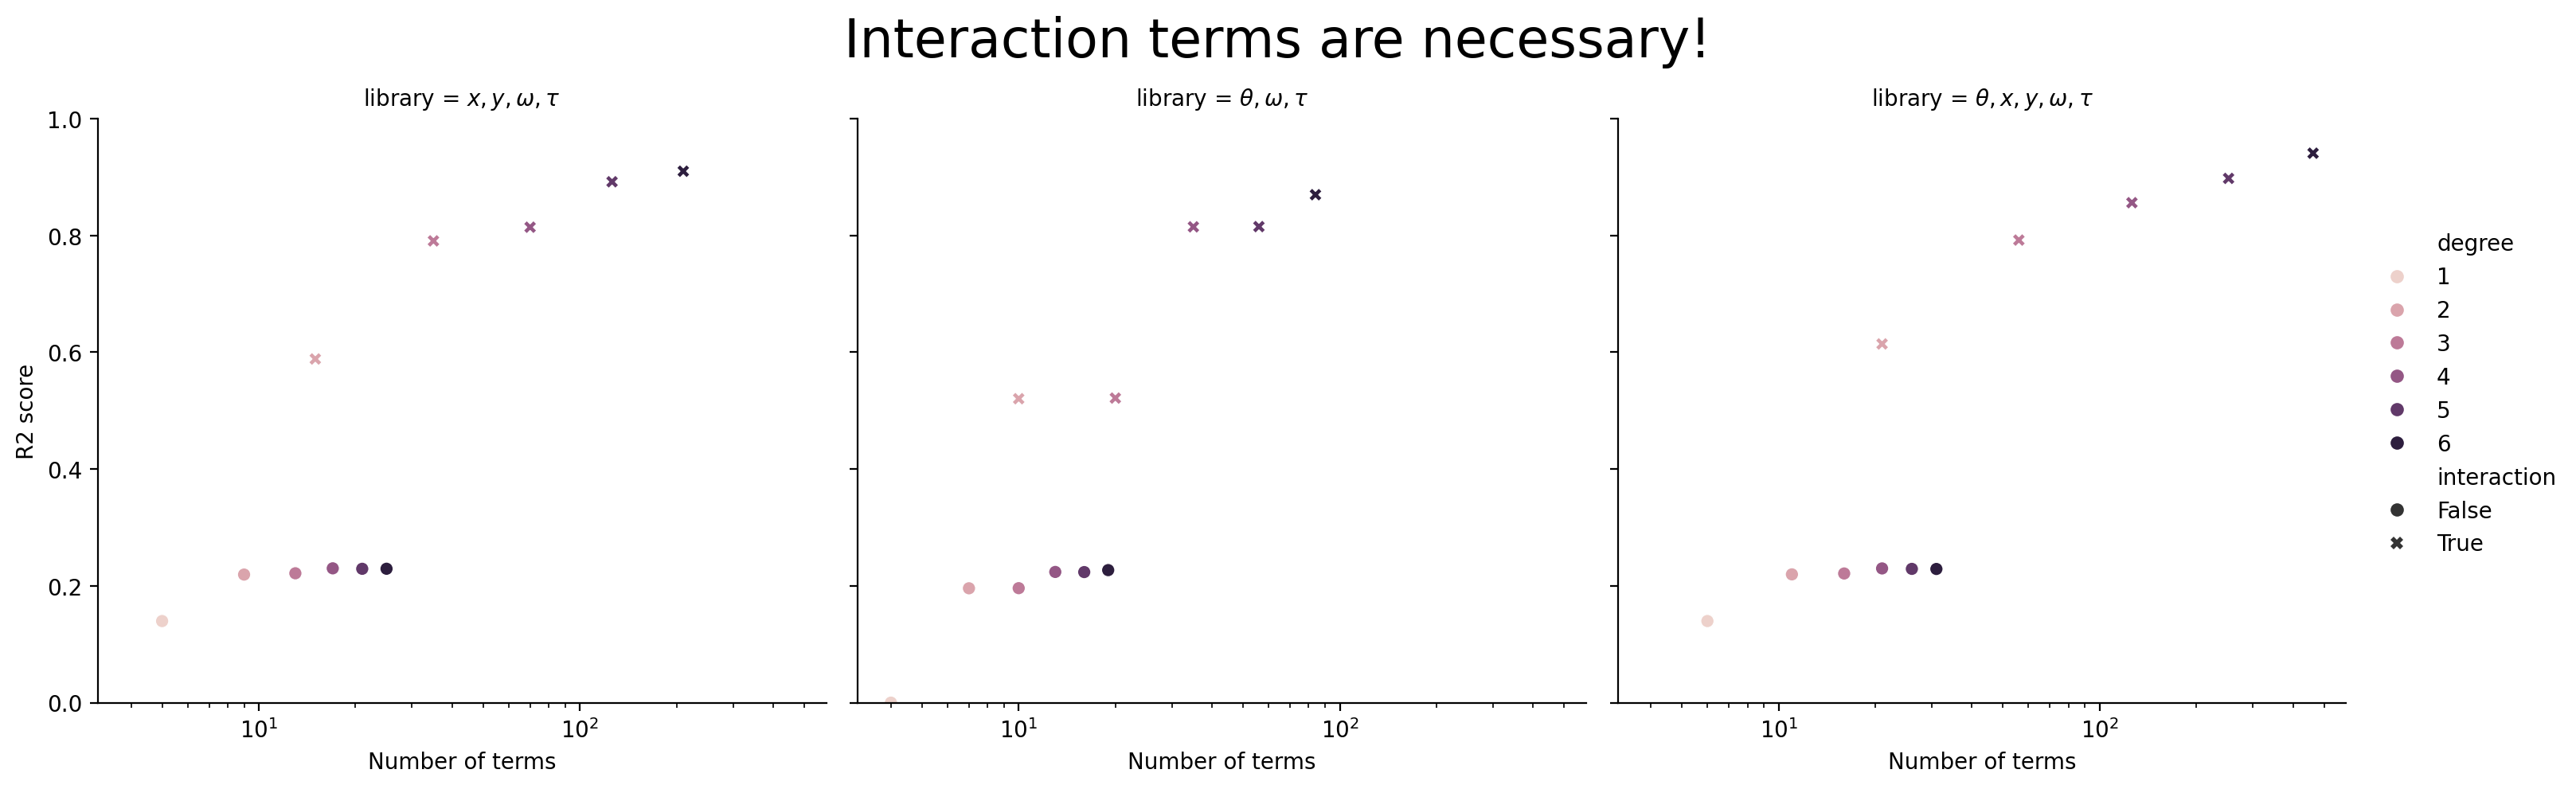

In [348]:
import seaborn as sns

p = sns.relplot(
    data=results,
    kind='scatter',
    col='library',
    x='num_terms',
    y='score',
    hue='degree',
    style='interaction'
)
p.set(xscale='log', ylim=[0, 1])
p.set(xlabel='Number of terms', ylabel='R2 score')
p.figure.suptitle('Interaction terms are necessary!', size=24)
p.figure.subplots_adjust(top=0.85)
#sns.move_legend(ax, loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

In [349]:
# Let's do a parameter sweep
import pandas as pd
results = pd.DataFrame(columns=['degree', 'interaction', 'score', 'num_terms', 'library'])

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

threshold=1e0
alpha=1e3

for degree in range(1, 7):
    for interaction in [True]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$x, y, \\omega, \\tau$']

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, \\omega, \\tau$']

inputs = np.concatenate([theta, np.cos(theta), np.sin(theta), omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, np.cos(test_theta), np.sin(test_theta), test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, x, y, \\omega, \\tau$']

results


(10000, 4) (10000, 1)
(10000, 3) (10000, 1)
(10000, 5) (10000, 1)


,degree,interaction,score,num_terms,library
0,1,True,0.139828,2,"$x, y, \omega, \tau$"
1,2,True,0.586334,7,"$x, y, \omega, \tau$"
2,3,True,0.587514,10,"$x, y, \omega, \tau$"
3,4,True,0.615079,24,"$x, y, \omega, \tau$"
4,5,True,0.615032,28,"$x, y, \omega, \tau$"
5,6,True,0.628818,58,"$x, y, \omega, \tau$"
6,1,True,0.000059,2,"$\theta, \omega, \tau$"
7,2,True,0.283651,6,"$\theta, \omega, \tau$"
8,3,True,0.401209,10,"$\theta, \omega, \tau$"
9,4,True,0.787577,18,"$\theta, \omega, \tau$"


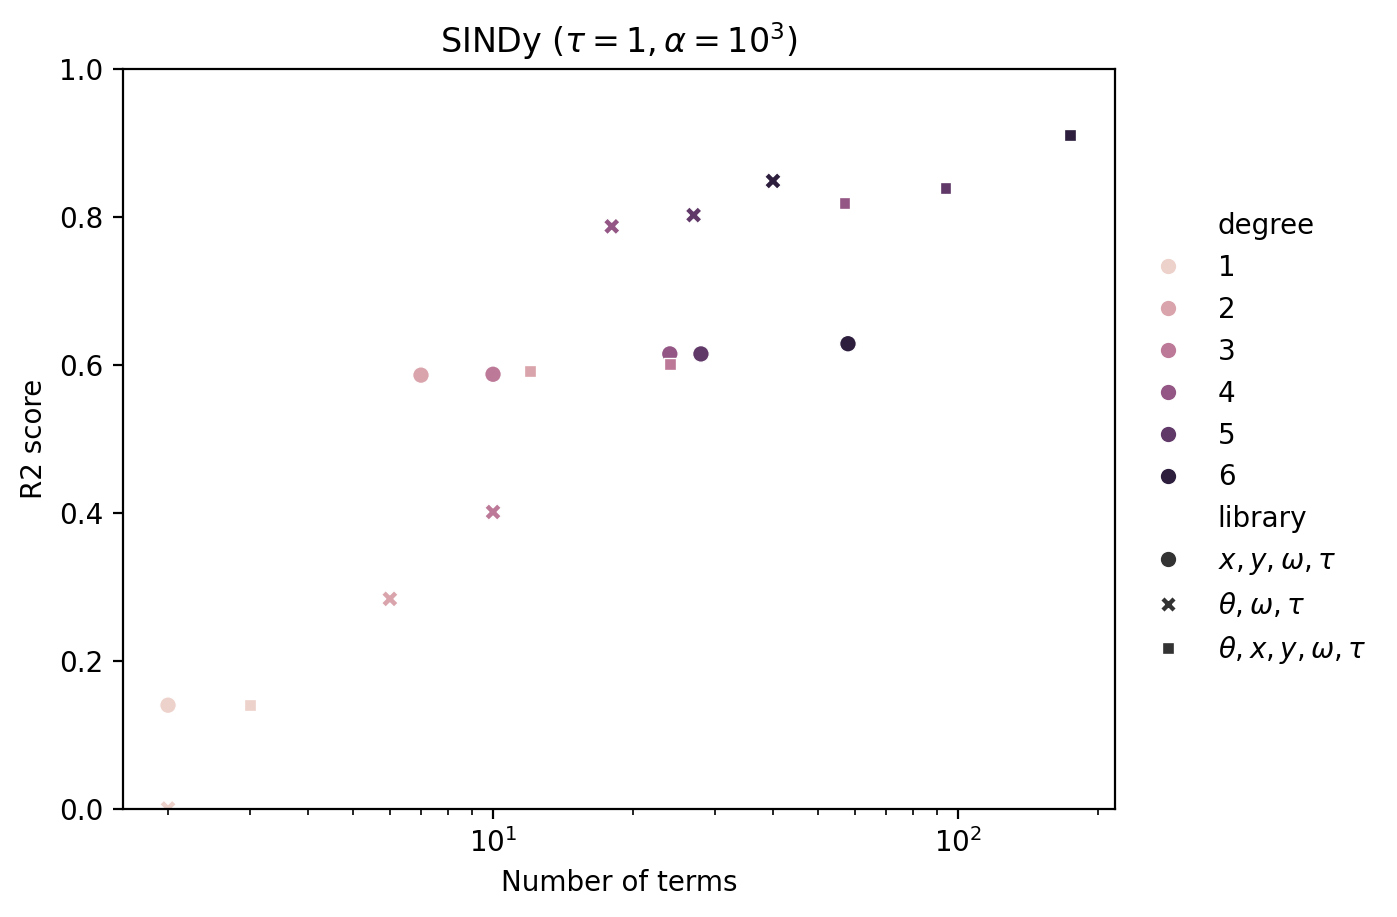

In [350]:
import seaborn as sns
plt.rcParams['figure.dpi'] = 200
p = sns.scatterplot(
    data=results[results.interaction],
    x='num_terms',
    y='score',
    hue='degree',
    style='library',
)
p.set(xscale='log', ylim=[0, 1])
p.set(xlabel='Number of terms', ylabel='R2 score', title='SINDy ($\\tau=1, \\alpha=10^3$)')
sns.move_legend(p, loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

# Examining the reward structure

(10000, 3) (10000, 1) (10000, 1) (10000, 1)
(10000, 3) (10000, 1)
Q = -1.000 th^2 + -0.100 w^2 + -0.001 T^2
R2 score is 1.000


Text(0.5, 0.98, 'Reward $(\\theta, \\omega, \\tau)$: 3 terms')

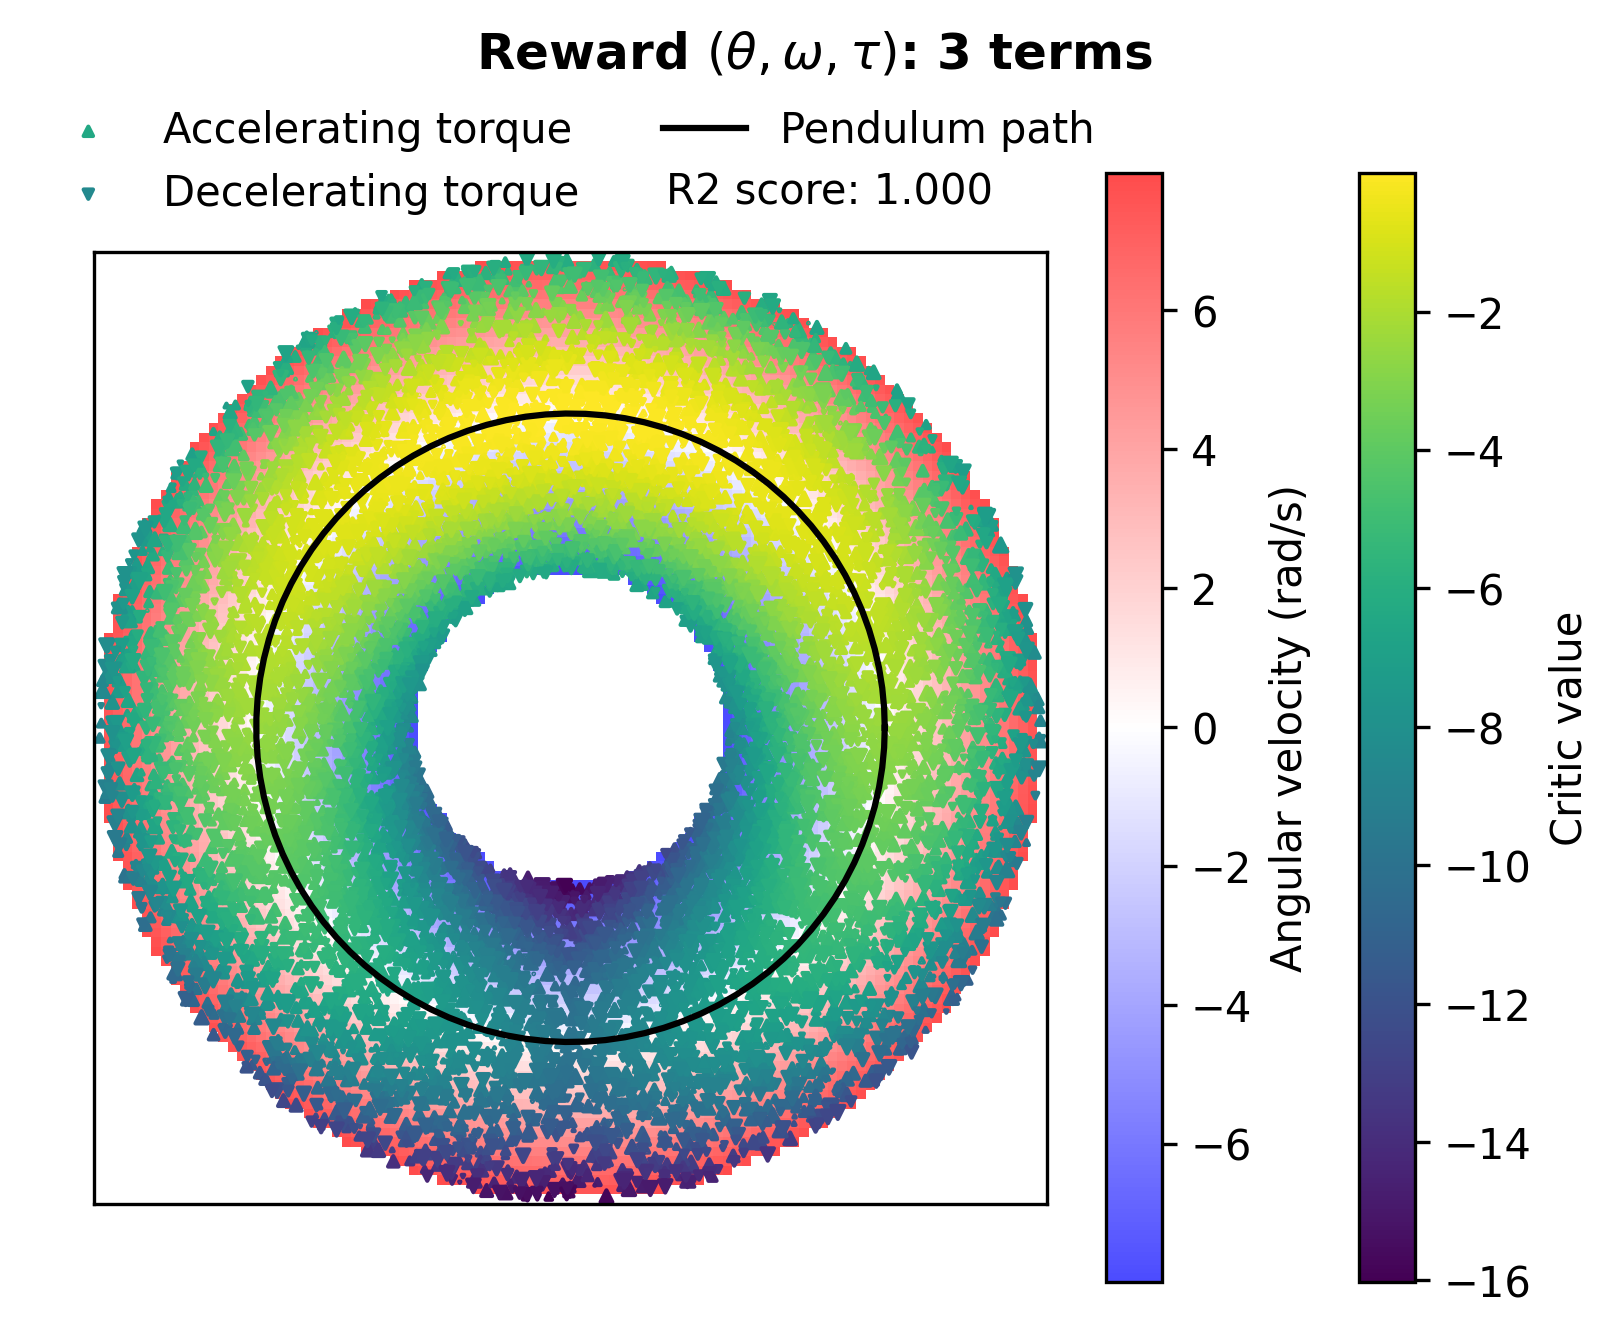

In [264]:
# Reward structure
import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

th = theta.copy()
th[th > np.pi] -= 2 * np.pi
test_th = test_theta.copy()
test_th[test_th > np.pi] -= 2 * np.pi

inputs = np.concatenate([th, omega, actions], axis=1)
targets = -(th**2 + 0.1*omega**2 + 0.001*actions**2).reshape([-1, 1])
#targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_th, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])
test_targets = -(test_th**2 + 0.1*test_omega**2 + 0.001*test_actions**2).reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=2, include_bias=False, include_interaction=False),
    optimizer=ps.STLSQ(threshold=1e1, alpha=1e1, normalize_columns=True),
    feature_names=['th', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)

# Radius corresponds to observed angular velocity
r = 1 + omega / 16. # Radius corresponds to angular velocity
t = 5 * np.abs(actions)# Size corresponds to torque magnitude

x = -r * np.sin(theta)
y = r * np.cos(theta)

mask = np.sign(actions * omega) >= 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 #vmin=-200, vmax=0,
                 cmap='viridis', marker='^', label='Accelerating torque')
mask = np.sign(actions * omega) < 0
im1 = ax.scatter(x[mask], y[mask], c=sindy_values[mask], s=t[mask], 
                 #vmin=-200, vmax=0,
                 cmap='viridis', marker='v', label='Decelerating torque')
plt.colorbar(im1, ax=ax, label='Critic value')

# Plot circle for pendulum path
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
        label='Pendulum path')

# Plot contours for angular velocity
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
O = (R - 1) * 16
O[np.abs(O) > 8] = np.nan

im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

ax.set(xticks=[], yticks=[], aspect='equal')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'Reward $(\\theta, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')